In [1]:
import numpy as np
from scipy.stats import beta, binom, bernoulli, betabinom

import matplotlib.pyplot as plt

# Urn Model

White=1, Black=0



In [2]:
urns = [1/3, 2/3]
# prior

urn = bernoulli.rvs(p=1/2, size=1)[0]
p = urns[urn]

bernoulli.rvs(p=p, size=1)[0]

np.int64(1)

What do we expect to see a priori?

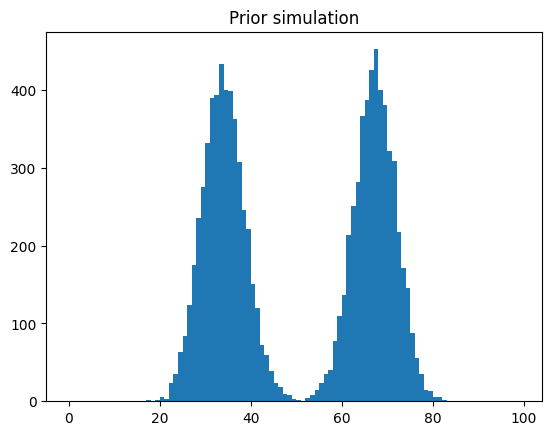

In [3]:
num_white = []

for i in range(10000):
  urn = bernoulli.rvs(p=1/2, size=1)[0]
  p = urns[urn]

  num_white.append(binom.rvs(p=p, n=100, size=1)[0])

plt.hist(num_white, bins=range(100))
plt.title('Prior simulation')
plt.show()

After updating

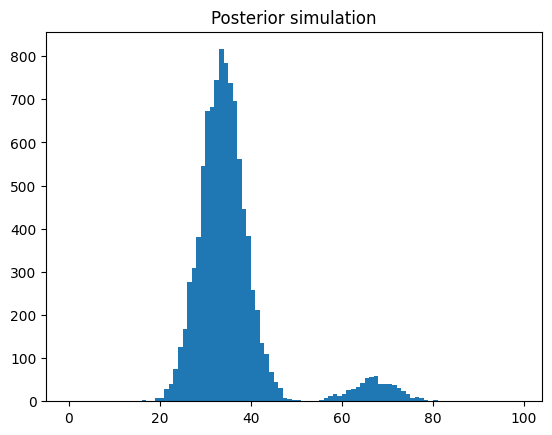

In [4]:
num_white = []

for i in range(10000):
  urn = bernoulli.rvs(p=1/17, size=1)[0]
  p = urns[urn]

  num_white.append(binom.rvs(p=p, n=100, size=1)[0])

plt.hist(num_white, bins=range(100))
plt.title('Posterior simulation')
plt.show()

## Beta-Binomial

Hyperparameters:

$\alpha=?$, $\beta=?$

Mean:

$$ E[Beta] = \frac{\alpha}{\alpha + \beta} $$

Possible symmetric priors ($\alpha=\beta$):

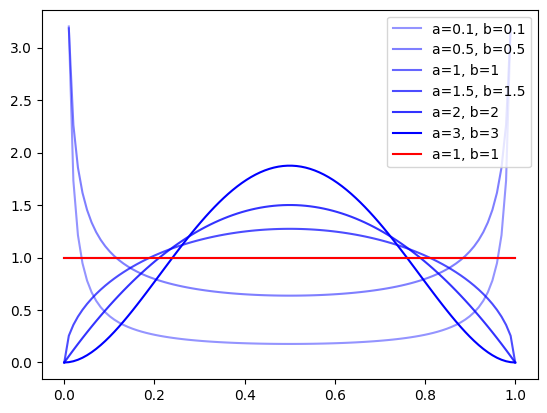

In [5]:
for i in [0.1,0.5,1,1.5,2,3]:
  plt.plot(np.linspace(0,1,100), beta.pdf(np.linspace(0,1,100), a=i, b=i), label=f'a={i}, b={i}', color='b', alpha=(i+2)/5)

plt.plot(np.linspace(0,1,100), beta.pdf(np.linspace(0,1,100), a=1, b=1), label=f'a=1, b=1', color='r', alpha=(i+2)/5)
plt.legend()
plt.show()

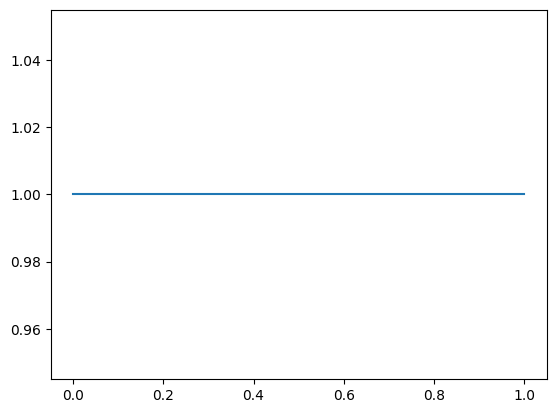

In [6]:
# hyperparameters
alpha_param = 1
beta_param = 1

pp = np.linspace(0,1,100)

plt.plot(np.linspace(0,1,100), beta.pdf(pp, a=alpha_param, b=beta_param))
plt.show()

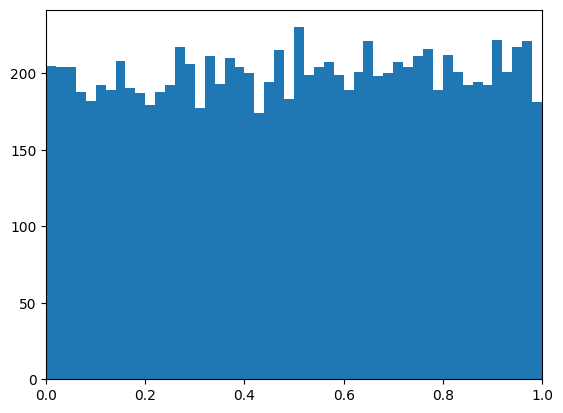

In [7]:
plt.hist(beta.rvs(a=alpha_param, b=beta_param, size=10000), bins=50)
plt.xlim(0,1)
plt.show()

Prior simulation:

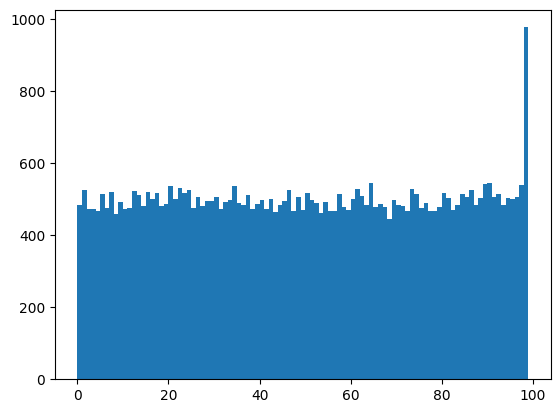

In [8]:
num_white = []

for i in range(50000):
    p = beta.rvs(a=alpha_param, b=beta_param, size=1)[0]
    num_white.append(binom.rvs(p=p, n=100, size=1)[0])

plt.hist(num_white, bins=range(100))
plt.show()

Posterior:

$ \alpha_{post} = 1 + \sum black = 1 + 7 = 8$

$ \beta_{post} = 1 + 10 - \sum black = 1 + 3 = 4$

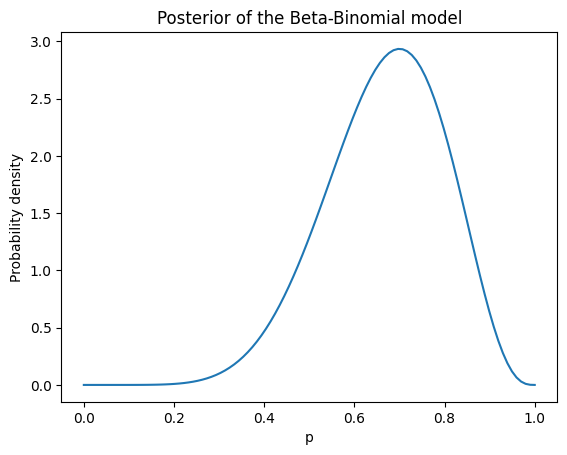

In [9]:
alpha_param = 8
beta_param = 4

pp = np.linspace(0,1,100)

plt.plot(pp, beta.pdf(pp, a=alpha_param, b=beta_param))
plt.xlabel('p')
plt.ylabel('Probability density')
plt.title('Posterior of the Beta-Binomial model')
plt.show()

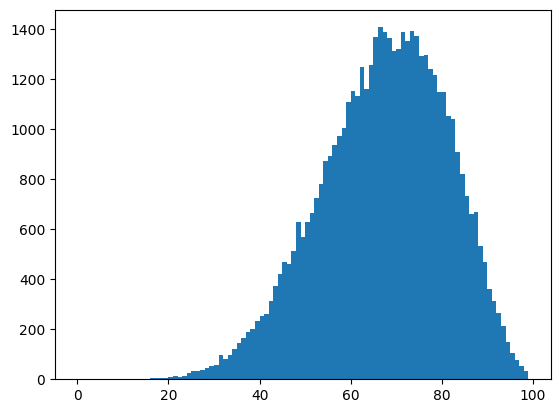

In [10]:
num_white = []

for i in range(50000):
    p = beta.rvs(a=alpha_param, b=beta_param, size=1)[0]
    num_white.append(binom.rvs(p=p, n=100, size=1)[0])

plt.hist(num_white, bins=range(100))
plt.show()

### Simulated example

We will simulate from the "true" model and update starting from the *prior*

In [11]:
# true model
p_true = 1/8
bernoulli.rvs(p=p_true, size=1)[0]

np.int64(0)

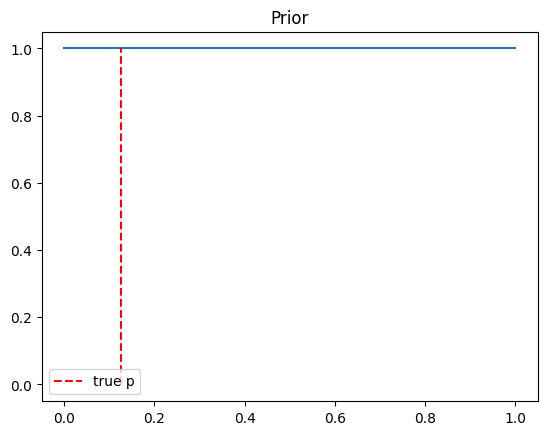

In [12]:
# prior

alpha_param = 1
beta_param = 1

pp = np.linspace(0,1,100)

plt.plot(pp, beta.pdf(pp, a=alpha_param, b=beta_param))
plt.title('Prior')
plt.vlines(x=1/8, ymin=0, ymax=1, color='r', linestyles='--', label='true p')
plt.legend()
plt.show()

We will update gradually, one datum at a time

In [13]:
data = []

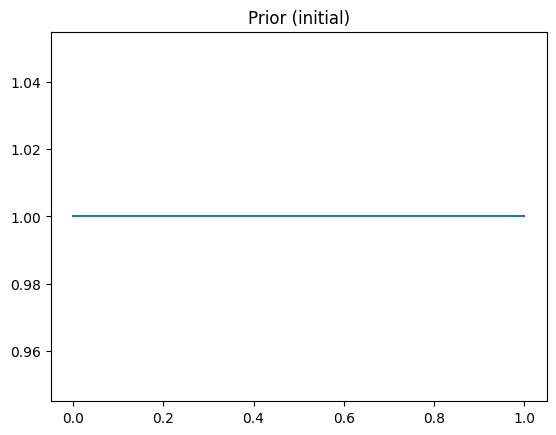

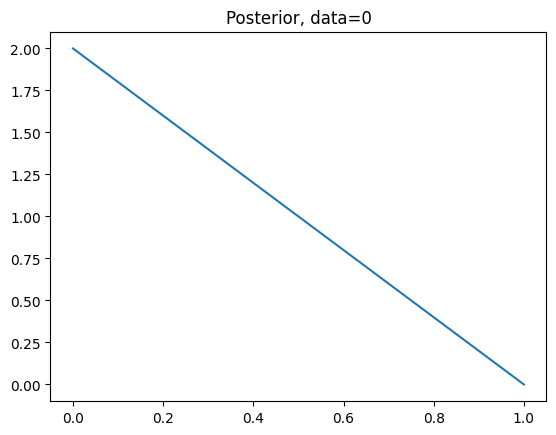

In [14]:
alpha_param = 1
beta_param = 1

pp = np.linspace(0,1,100)

plt.plot(pp, beta.pdf(pp, a=alpha_param, b=beta_param))
plt.title('Prior (initial)')
plt.show()

data.append(bernoulli.rvs(p=p_true, size=1)[0])
data_str = ','.join([str(x) for x in data])

alpha_param = alpha_param + sum(data)
beta_param = beta_param + len(data) - sum(data)

plt.plot(pp, beta.pdf(pp, a=alpha_param, b=beta_param))
plt.title(f'Posterior, data={data_str}')
plt.show()

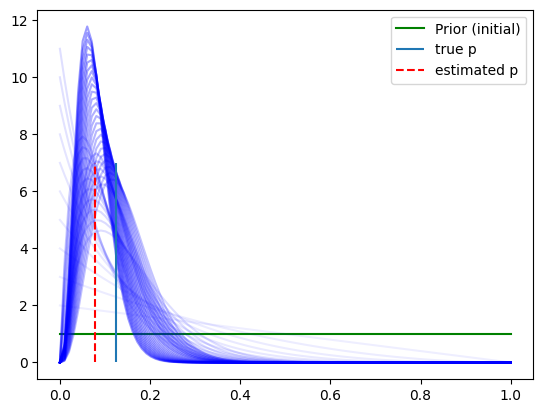

In [15]:
np.random.seed(15)

alpha_param = 1
beta_param = 1

pp = np.linspace(0,1,100)

plt.plot(pp,beta.pdf(pp, a=alpha_param, b=beta_param), label='Prior (initial)', color='g')

data = []

for i in range(50): # increase
  data.append(bernoulli.rvs(p=p_true, size=1)[0])

  alpha_param_post = alpha_param + sum(data)
  beta_param_post = beta_param + len(data) - sum(data)

  plt.plot(pp, beta.pdf(pp, a=alpha_param_post, b=beta_param_post), color='b', alpha=(i*10+100)/1500)

plt.vlines(x=p_true, ymin=0, ymax=7, label='true p')
plt.vlines(x=beta.mean(a=alpha_param_post, b=beta_param_post), ymin=0, ymax=7, label='estimated p', color='r', linestyles='--')
plt.legend()
plt.show()

In [16]:
beta.mean(a=alpha_param_post, b=beta_param_post)

np.float64(0.07692307692307693)

In [17]:
np.mean(data)

np.float64(0.06)

In [18]:
1/8

0.125

Different prior:

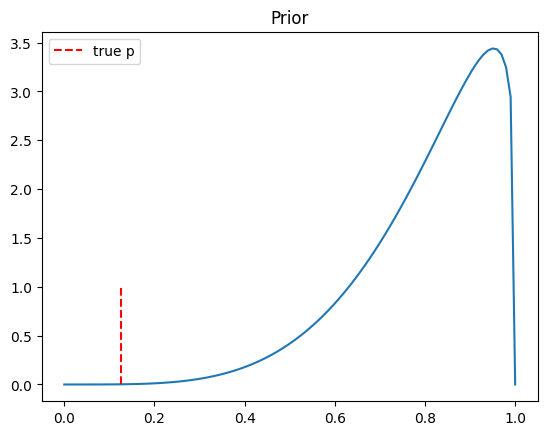

In [19]:
# prior

alpha_param = 5
beta_param = 1.2

pp = np.linspace(0,1,100)

plt.plot(pp, beta.pdf(pp, a=alpha_param, b=beta_param))
plt.title('Prior')
plt.vlines(x=1/8, ymin=0, ymax=1, color='r', linestyles='--', label='true p')
plt.legend()
plt.show()

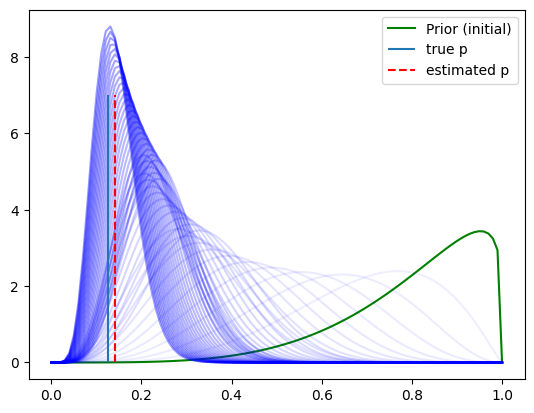

In [20]:
np.random.seed(15)

alpha_param = 5
beta_param = 1.2

pp = np.linspace(0,1,100)

plt.plot(pp,beta.pdf(pp, a=alpha_param, b=beta_param), label='Prior (initial)', color='g')

data = []

for i in range(50):
  data.append(bernoulli.rvs(p=p_true, size=1)[0])

  alpha_param_post = alpha_param + sum(data)
  beta_param_post = beta_param + len(data) - sum(data)

  pp = np.linspace(0,1,100)

  plt.plot(pp, beta.pdf(pp, a=alpha_param_post, b=beta_param_post), color='b', alpha=(i*10+100)/1500)

plt.vlines(x=p_true, ymin=0, ymax=7, label='true p')
plt.vlines(x=beta.mean(a=alpha_param_post, b=beta_param_post), ymin=0, ymax=7, label='estimated p', color='r', linestyles='--')
plt.legend()
plt.show()

In [21]:
beta.mean(a=alpha_param_post, b=beta_param_post)

np.float64(0.14234875444839856)

In [22]:
np.mean(data)

np.float64(0.06)

In [23]:
1/8

0.125

### Predictive

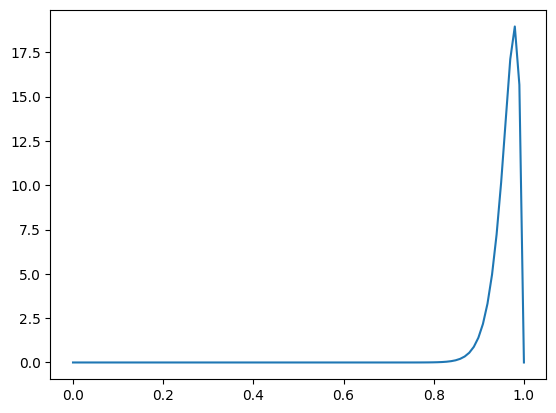

In [24]:
plt.plot(pp, beta.pdf(pp, a=50, b=2))

In [25]:
p_true = 1/8

data = bernoulli.rvs(p=p_true, size=100)

alpha_param_post = 2 + sum(data)
beta_param_post = 2 + len(data) - sum(data)

In [26]:
beta.mean(a=alpha_param_post, b=beta_param_post)

np.float64(0.14423076923076922)

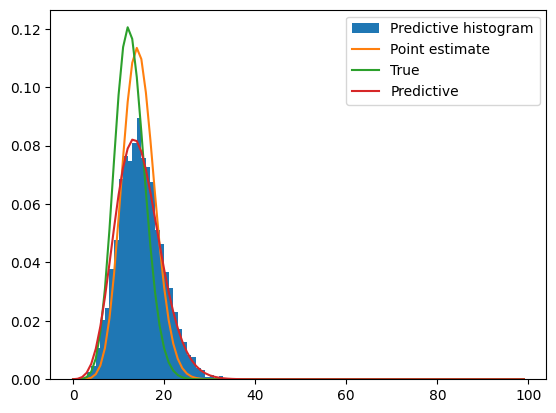

In [27]:
num_white = []

for i in range(5000):
    p = beta.rvs(a=alpha_param_post, b=beta_param_post, size=1)[0]
    num_white.append(binom.rvs(p=p, n=100, size=1)[0])

plt.hist(num_white, bins=range(100), density=True, label='Predictive histogram')
plt.plot(binom.pmf(range(100), p=alpha_param_post/(alpha_param_post+beta_param_post), n=100), label='Point estimate')
plt.plot(binom.pmf(range(100), p=p_true, n=100), label='True')
plt.plot(betabinom.pmf(range(100), a=alpha_param_post, b=beta_param_post, n=100), label='Predictive')
plt.legend()
plt.show()

In [28]:
alpha_param_post/(alpha_param_post+beta_param_post)

np.float64(0.14423076923076922)

### Question

* What is the probability that fewer than half of the balls are white?

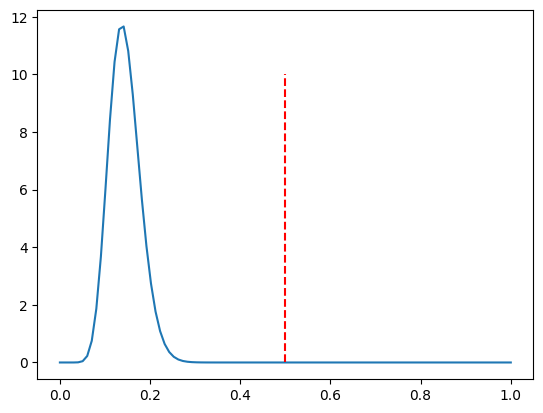

In [29]:
plt.plot(np.linspace(0,1,100), beta.pdf(np.linspace(0,1,100), a=alpha_param_post, b=beta_param_post))
plt.vlines(x=1/2, ymin=0, ymax=10, color='r', linestyles='--')

In [30]:
1-beta.cdf(1/2, a=alpha_param_post, b=beta_param_post)

np.float64(7.993605777301127e-15)

# Utility Function